In [1]:
from pathlib import Path

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'
OUTPUT_DIR = DATA_DIR

# 05 — Decomposição STL
**Grupo 1 | Séries Temporais**

Decomposição STL (*Seasonal and Trend decomposition using Loess*) da série de preço de fechamento do Bitcoin.  
A decomposição separa a série em três componentes: **Tendência**, **Sazonalidade** e **Resíduo**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import STL
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 11
})

RANDOM_STATE = 42
TRAIN_RATIO  = 0.70

In [3]:
df = pd.read_csv(DATA_DIR / 'bitcoin_limpo.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df.set_index('date')
print(f'Base carregada: {df.shape}')
print(f'Período: {df.index.min().date()} → {df.index.max().date()}')

Base carregada: (2943, 9)
Período: 2018-08-22 → 2026-09-11


## 1. Configuração da Decomposição STL

A STL requer a especificação do **período sazonal**. Para a série diária do Bitcoin, testamos:
- `period=7` — sazonalidade semanal (7 dias)
- `period=30` — sazonalidade mensal (≈30 dias)
- `period=365` — sazonalidade anual (365 dias)

Bitcoin opera 24/7, sem feriados fixos. A sazonalidade esperada é **semanal** (volume e comportamento diferente no fim de semana).

In [4]:
serie = df['priceClose'].copy()

# ── STL com período semanal (7 dias)
stl_7 = STL(serie, period=7, robust=True)
res_7 = stl_7.fit()

# ── STL com período mensal (30 dias)
stl_30 = STL(serie, period=30, robust=True)
res_30 = stl_30.fit()

# ── STL com período anual (365 dias)
stl_365 = STL(serie, period=365, robust=True)
res_365 = stl_365.fit()

print('Decomposições STL concluídas:')
print('  STL(period=7)   — sazonalidade semanal')
print('  STL(period=30)  — sazonalidade mensal')
print('  STL(period=365) — sazonalidade anual')

Decomposições STL concluídas:
  STL(period=7)   — sazonalidade semanal
  STL(period=30)  — sazonalidade mensal
  STL(period=365) — sazonalidade anual


## 2. Visualização da Decomposição STL — Período Semanal (7 dias)

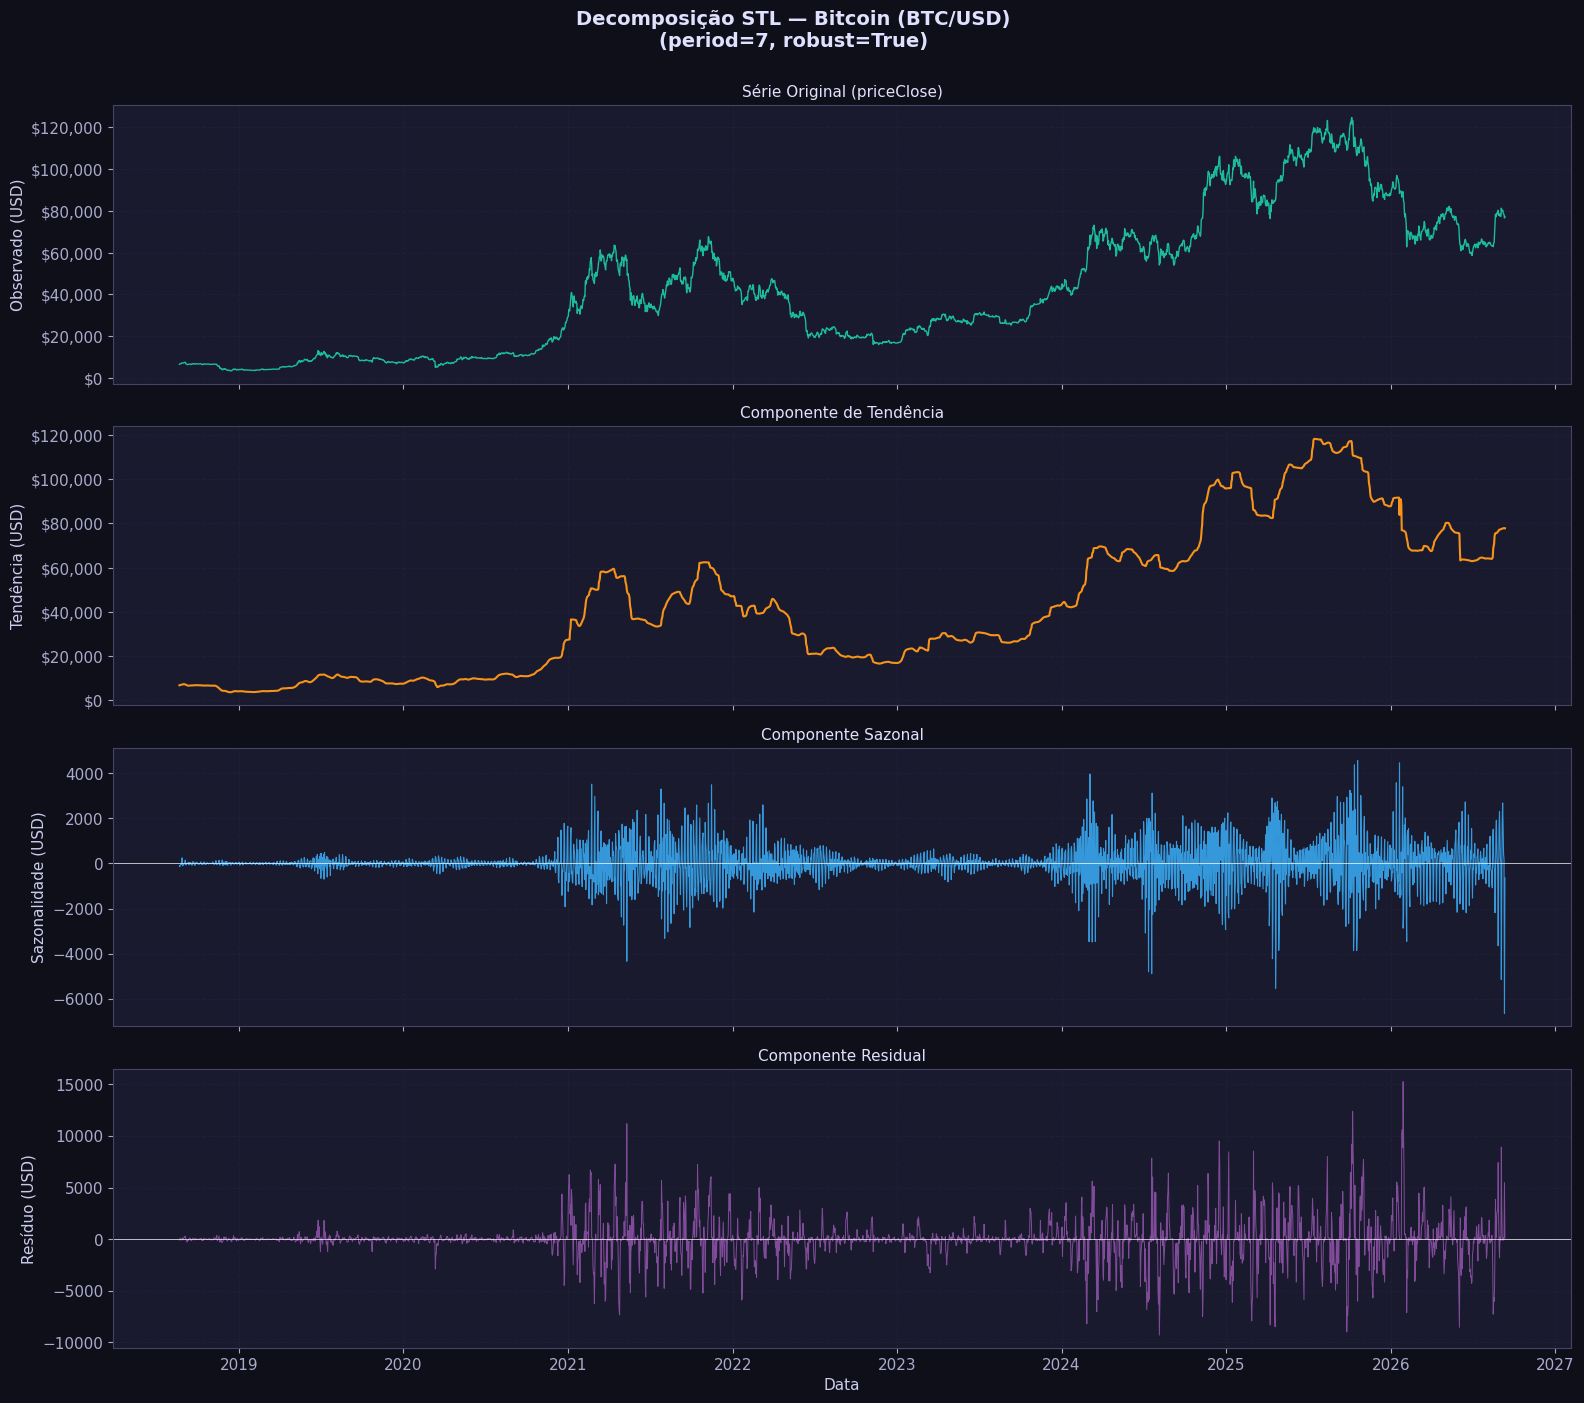

In [5]:
def plot_stl(resultado, titulo, periodo, cor_trend='#f7931a', cor_saz='#3498db',
             cor_res='#9b59b6', cor_obs='#1abc9c', filename=None):
    """
    Plota os 4 painéis da decomposição STL com estilo dark.
    """
    fig, axes = plt.subplots(4, 1, figsize=(16, 14), facecolor='#0f0f1a',
                             sharex=True)
    fig.suptitle(f'Decomposição STL — {titulo}\n(period={periodo}, robust=True)',
                 color='#e0e0ff', fontsize=14, fontweight='bold', y=1.00)

    idx = resultado.observed.index

    # Série observada
    axes[0].plot(idx, resultado.observed, color=cor_obs, linewidth=1)
    axes[0].set_ylabel('Observado (USD)')
    axes[0].set_title('Série Original (priceClose)', color='#e0e0ff', fontsize=11)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    # Tendência
    axes[1].plot(idx, resultado.trend, color=cor_trend, linewidth=1.5)
    axes[1].set_ylabel('Tendência (USD)')
    axes[1].set_title('Componente de Tendência', color='#e0e0ff', fontsize=11)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    # Sazonalidade
    axes[2].plot(idx, resultado.seasonal, color=cor_saz, linewidth=0.8)
    axes[2].axhline(0, color='#ffffff', linewidth=0.5)
    axes[2].set_ylabel('Sazonalidade (USD)')
    axes[2].set_title('Componente Sazonal', color='#e0e0ff', fontsize=11)

    # Resíduo
    axes[3].plot(idx, resultado.resid, color=cor_res, linewidth=0.7, alpha=0.8)
    axes[3].axhline(0, color='#ffffff', linewidth=0.5)
    axes[3].set_ylabel('Resíduo (USD)')
    axes[3].set_xlabel('Data')
    axes[3].set_title('Componente Residual', color='#e0e0ff', fontsize=11)

    for ax in axes:
        ax.set_facecolor('#1a1a2e')
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()

plot_stl(res_7, 'Bitcoin (BTC/USD)', 7, filename=OUTPUT_DIR / 'plot_12_stl_period7.png')

## 3. Visualização da Decomposição STL — Período Anual (365 dias)

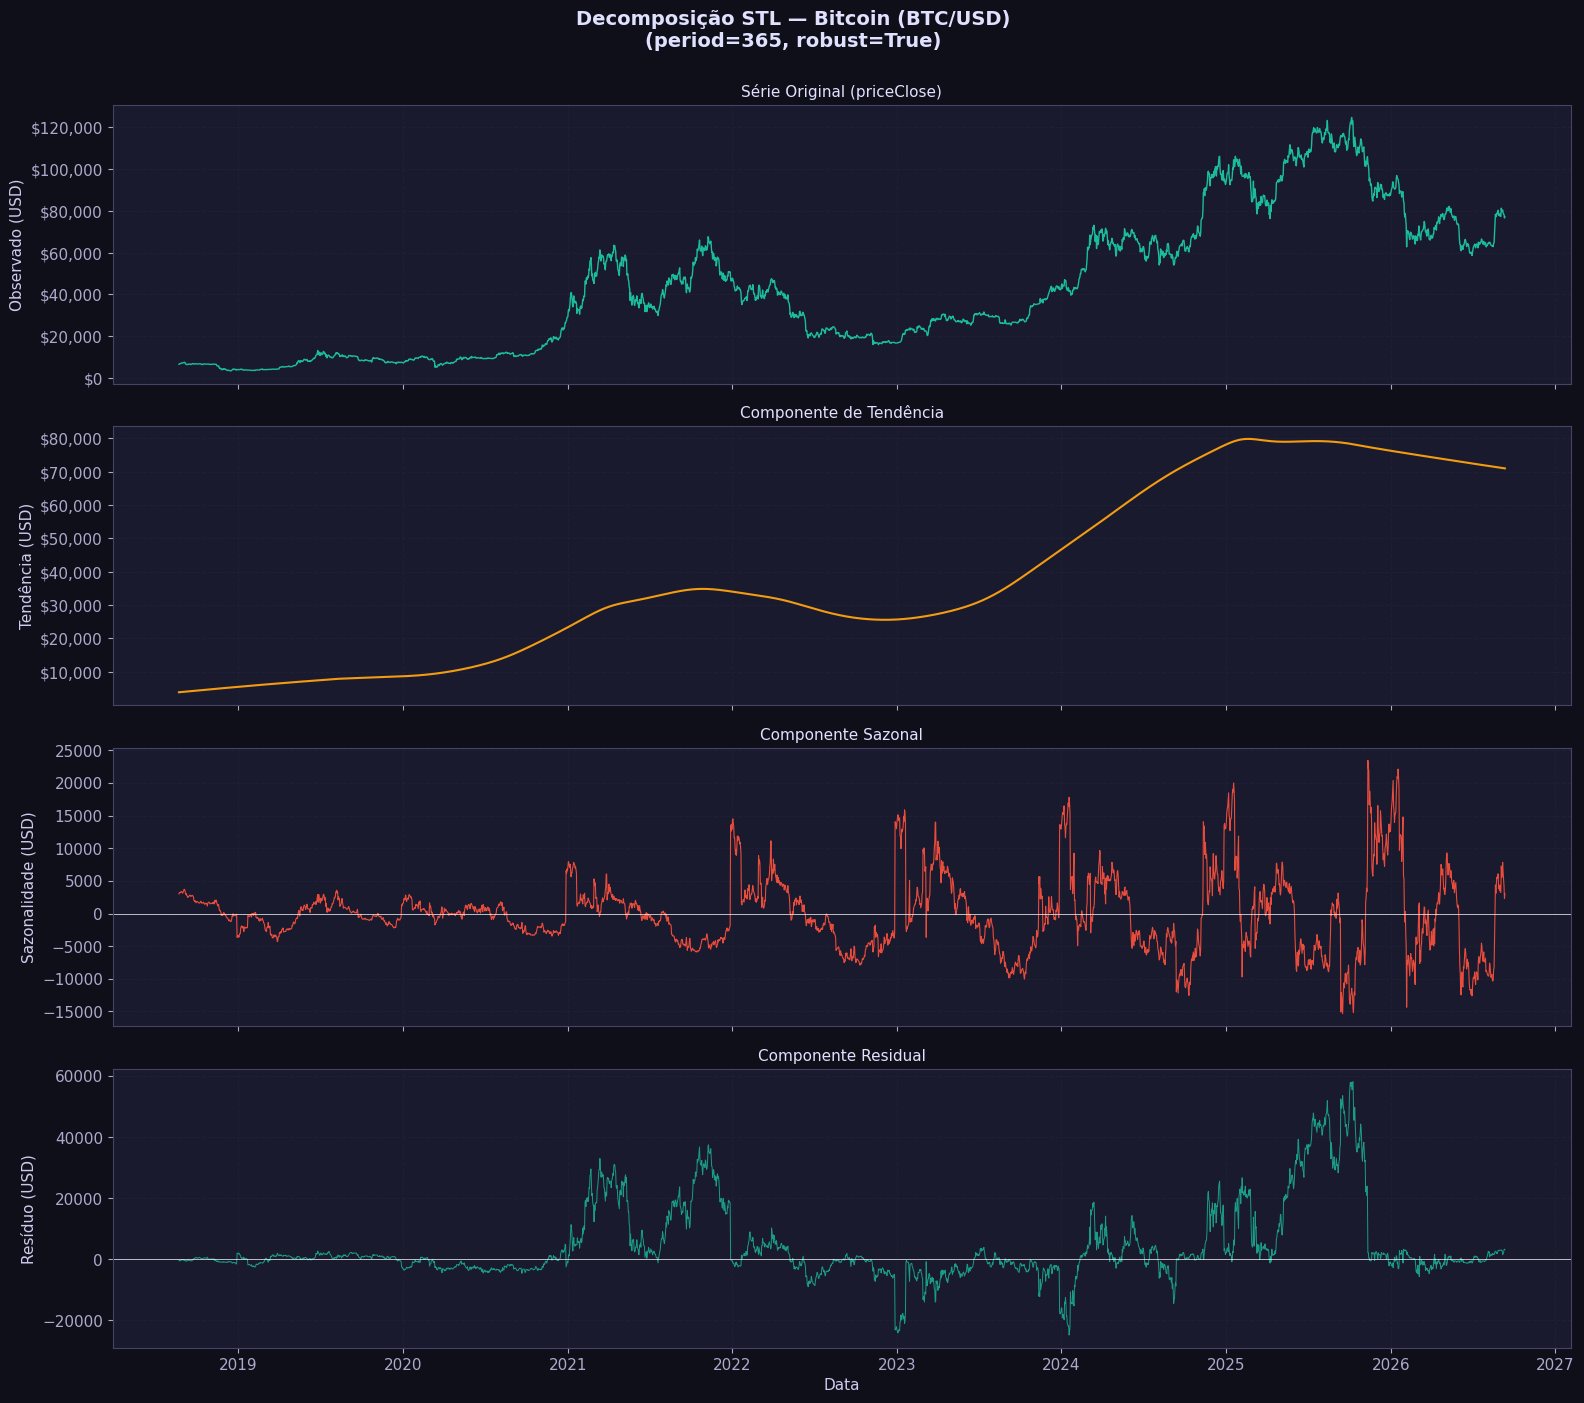

In [6]:
plot_stl(res_365, 'Bitcoin (BTC/USD)', 365, 
         cor_trend='#f39c12', cor_saz='#e74c3c', cor_res='#1abc9c',
         filename=OUTPUT_DIR / 'plot_13_stl_period365.png')

## 4. Análise da Tendência

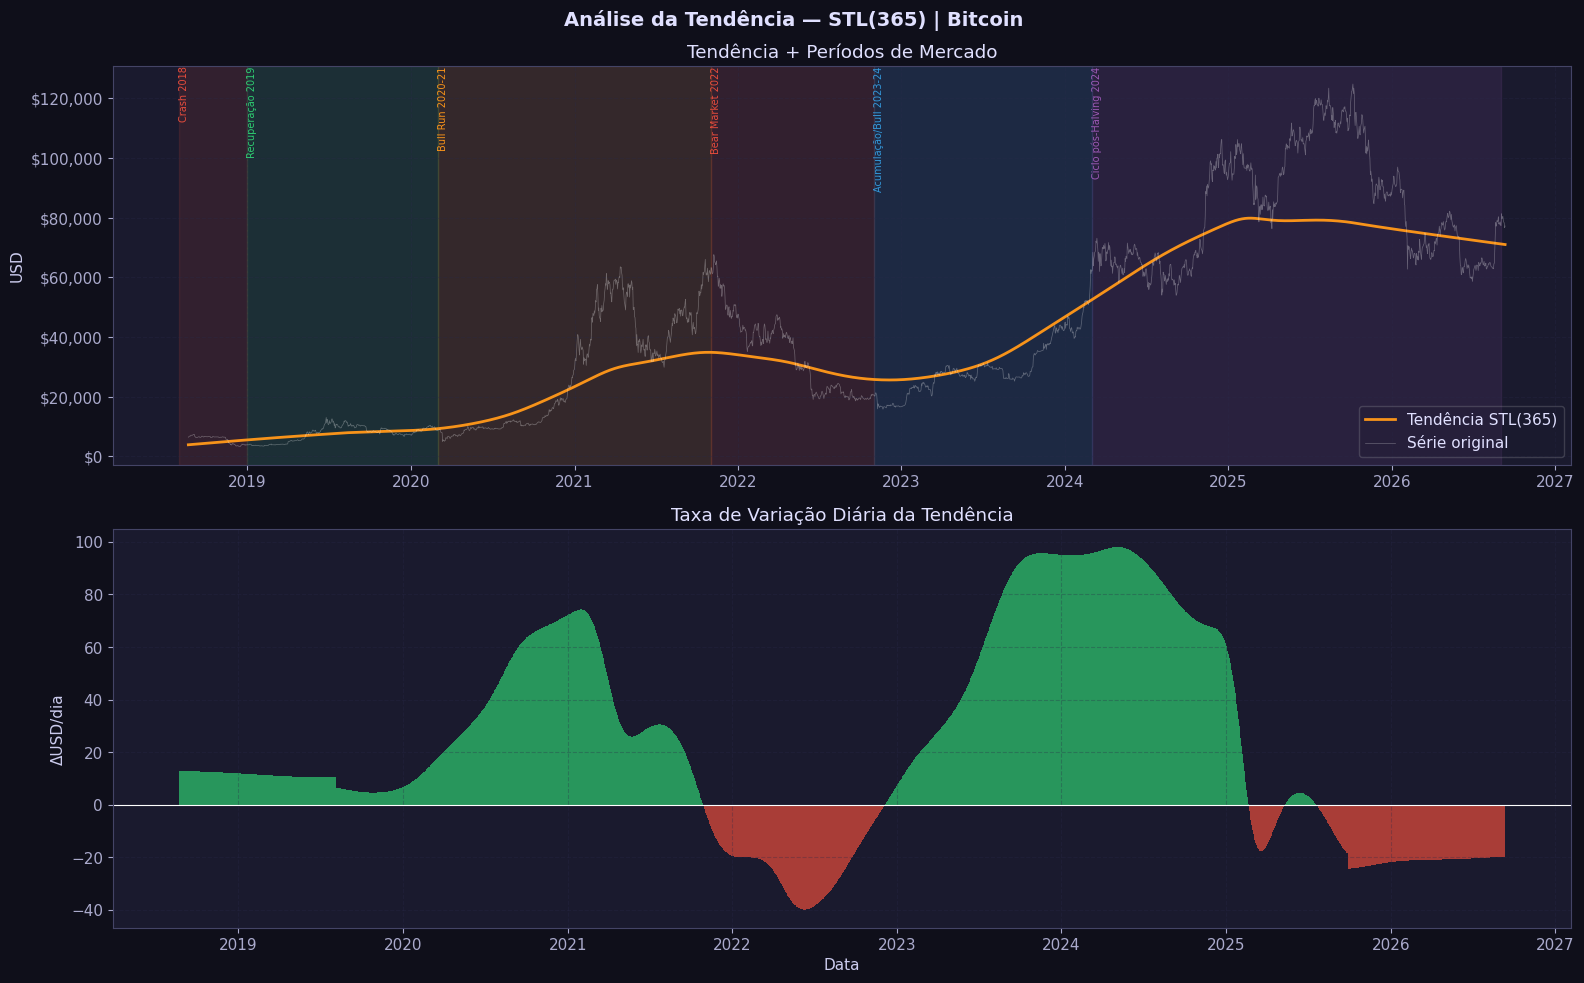

In [7]:
# Usando o STL anual que captura melhor a tendência macro
trend = pd.Series(res_365.trend, index=serie.index)

# Identificar períodos de crescimento, queda e estabilidade
trend_diff = trend.diff()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), facecolor='#0f0f1a')
fig.suptitle('Análise da Tendência — STL(365) | Bitcoin', 
             color='#e0e0ff', fontsize=14, fontweight='bold')

# Tendência com regiões coloridas
ax1 = axes[0]
ax1.plot(trend.index, trend.values, color='#f7931a', linewidth=2, label='Tendência STL(365)')
ax1.plot(serie.index, serie.values, color='#ffffff', linewidth=0.5, alpha=0.3, label='Série original')

# Períodos notáveis
periodos = [
    ('2018-08', '2019-01', 'Crash 2018', '#e74c3c'),
    ('2019-01', '2020-03', 'Recuperação 2019', '#2ecc71'),
    ('2020-03', '2021-11', 'Bull Run 2020-21', '#f7931a'),
    ('2021-11', '2022-11', 'Bear Market 2022', '#e74c3c'),
    ('2022-11', '2024-03', 'Acumulação/Bull 2023-24', '#3498db'),
    ('2024-03', '2026-09', 'Ciclo pós-Halving 2024', '#9b59b6'),
]
for inicio, fim, label, cor in periodos:
    ax1.axvspan(pd.Timestamp(inicio), pd.Timestamp(fim), alpha=0.12, color=cor)
    ax1.text(pd.Timestamp(inicio), ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 80000, 
             label, color=cor, fontsize=7, rotation=90, va='top', ha='left')

ax1.set_title('Tendência + Períodos de Mercado', color='#e0e0ff')
ax1.set_ylabel('USD')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(framealpha=0.2)
ax1.grid(True, alpha=0.3)

# Taxa de variação da tendência
ax2 = axes[1]
cores_diff = ['#2ecc71' if v >= 0 else '#e74c3c' for v in trend_diff.fillna(0)]
ax2.bar(trend_diff.index, trend_diff.values, color=cores_diff, alpha=0.7, width=1)
ax2.axhline(0, color='#ffffff', linewidth=0.8)
ax2.set_title('Taxa de Variação Diária da Tendência', color='#e0e0ff')
ax2.set_ylabel('ΔUSD/dia')
ax2.set_xlabel('Data')
ax2.grid(True, alpha=0.3)

for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_14_tendencia.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 5. Força da Sazonalidade

A força da sazonalidade é calculada conforme a fórmula apresentada em sala:

$$F_s = \max\left(0, 1 - \frac{\text{Var}(R_t)}{\text{Var}(S_t + R_t)}\right)$$

Onde $R_t$ é o componente residual e $S_t$ o componente sazonal da decomposição STL.

In [8]:
def forca_sazonalidade(resultado, nome_periodo):
    """Calcula a força da sazonalidade e da tendência conforme Hyndman & Athanasopoulos."""
    R = resultado.resid
    S = resultado.seasonal
    T = resultado.trend

    var_R = np.var(R)
    var_SR = np.var(S + R)
    var_TR = np.var(T + R)
    var_obs = np.var(resultado.observed)

    Fs = max(0, 1 - var_R / var_SR) if var_SR > 0 else 0
    Ft = max(0, 1 - var_R / var_TR) if var_TR > 0 else 0

    print(f'\n  Período {nome_periodo}:')
    print(f'    Força da Sazonalidade (Fs) = {Fs:.4f}  {'→ Sazonalidade FORTE' if Fs > 0.6 else '→ Sazonalidade MODERADA' if Fs > 0.3 else '→ Sazonalidade FRACA'}')
    print(f'    Força da Tendência    (Ft) = {Ft:.4f}  {'→ Tendência FORTE' if Ft > 0.6 else '→ Tendência MODERADA' if Ft > 0.3 else '→ Tendência FRACA'}')
    print(f'    Var(R)      = {var_R:.2f}')
    print(f'    Var(S+R)    = {var_SR:.2f}')
    print(f'    Var(T+R)    = {var_TR:.2f}')
    return Fs, Ft

print('=== Força da Sazonalidade e Tendência ===')
Fs7,  Ft7  = forca_sazonalidade(res_7,   'semanal (7d)')
Fs30, Ft30 = forca_sazonalidade(res_30,  'mensal (30d)')
Fs365, Ft365 = forca_sazonalidade(res_365, 'anual (365d)')

=== Força da Sazonalidade e Tendência ===

  Período semanal (7d):
    Força da Sazonalidade (Fs) = 0.0000  → Sazonalidade FRACA
    Força da Tendência    (Ft) = 0.9967  → Tendência FORTE
    Var(R)      = 3501130.96
    Var(S+R)    = 3206036.34
    Var(T+R)    = 1050972313.60

  Período mensal (30d):
    Força da Sazonalidade (Fs) = 0.0000  → Sazonalidade FRACA
    Força da Tendência    (Ft) = 0.9897  → Tendência FORTE
    Var(R)      = 10798623.55
    Var(S+R)    = 10171048.91
    Var(T+R)    = 1051115212.99

  Período anual (365d):
    Força da Sazonalidade (Fs) = 0.0000  → Sazonalidade FRACA
    Força da Tendência    (Ft) = 0.8590  → Tendência FORTE
    Var(R)      = 150016061.40
    Var(S+R)    = 141257571.55
    Var(T+R)    = 1063750541.73


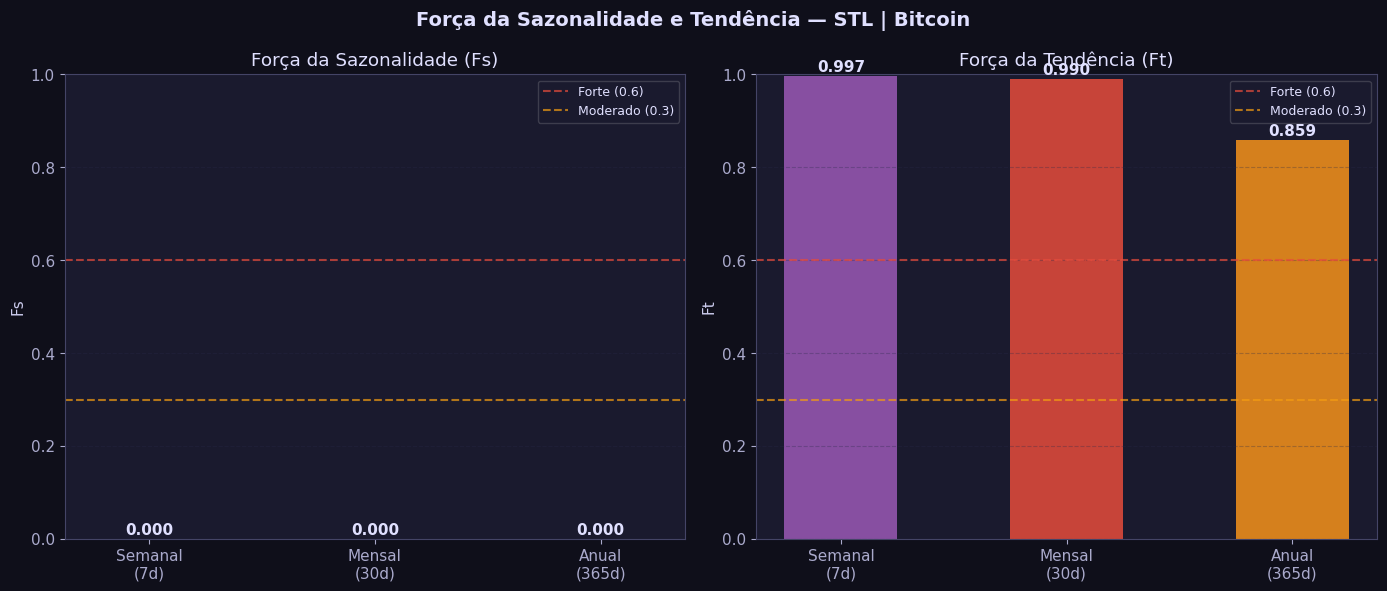

In [9]:
# Visualização das forças
periodos_nomes = ['Semanal\n(7d)', 'Mensal\n(30d)', 'Anual\n(365d)']
Fs_vals = [Fs7, Fs30, Fs365]
Ft_vals = [Ft7, Ft30, Ft365]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0f0f1a')
fig.suptitle('Força da Sazonalidade e Tendência — STL | Bitcoin',
             color='#e0e0ff', fontsize=14, fontweight='bold')

x = np.arange(len(periodos_nomes))
bars = axes[0].bar(x, Fs_vals, color=['#3498db','#2ecc71','#f39c12'], alpha=0.85, width=0.5)
axes[0].set_title('Força da Sazonalidade (Fs)', color='#e0e0ff')
axes[0].set_xticks(x)
axes[0].set_xticklabels(periodos_nomes)
axes[0].set_ylabel('Fs')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.6, color='#e74c3c', linestyle='--', alpha=0.7, linewidth=1.5, label='Forte (0.6)')
axes[0].axhline(0.3, color='#f39c12', linestyle='--', alpha=0.7, linewidth=1.5, label='Moderado (0.3)')
axes[0].legend(framealpha=0.2, fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, Fs_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', color='#e0e0ff', fontsize=11, fontweight='bold')

bars2 = axes[1].bar(x, Ft_vals, color=['#9b59b6','#e74c3c','#f7931a'], alpha=0.85, width=0.5)
axes[1].set_title('Força da Tendência (Ft)', color='#e0e0ff')
axes[1].set_xticks(x)
axes[1].set_xticklabels(periodos_nomes)
axes[1].set_ylabel('Ft')
axes[1].set_ylim(0, 1)
axes[1].axhline(0.6, color='#e74c3c', linestyle='--', alpha=0.7, linewidth=1.5, label='Forte (0.6)')
axes[1].axhline(0.3, color='#f39c12', linestyle='--', alpha=0.7, linewidth=1.5, label='Moderado (0.3)')
axes[1].legend(framealpha=0.2, fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, Ft_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', color='#e0e0ff', fontsize=11, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_15_forca_sazonalidade.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 6. Padrão Sazonal por Dia da Semana

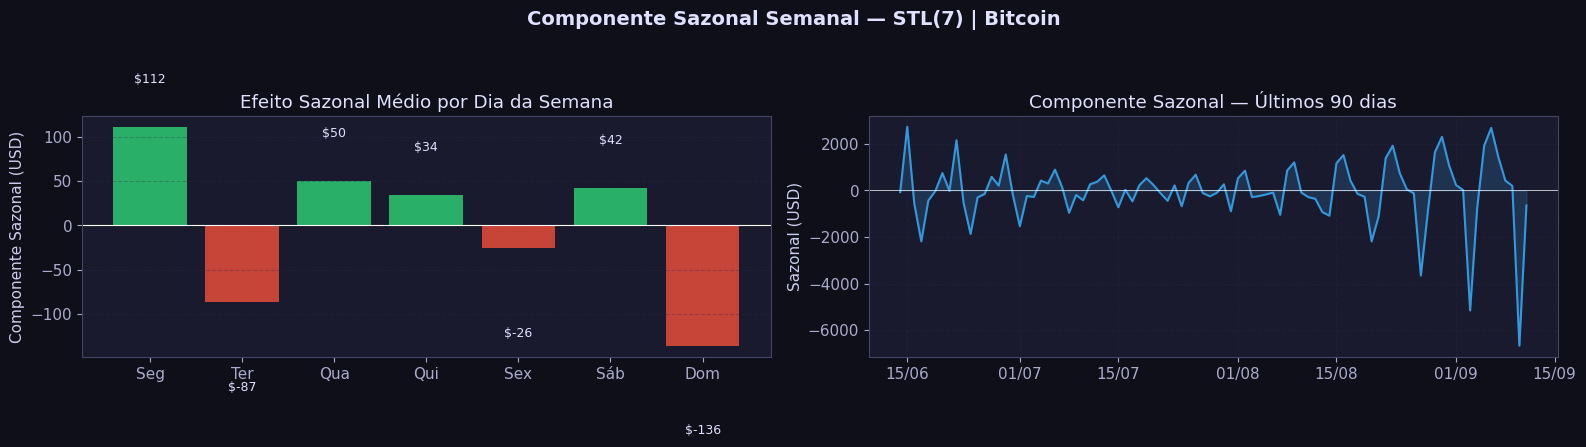

In [10]:
# Extrair o componente sazonal semanal e analisar o padrão médio por dia da semana
sazonal_7 = pd.Series(res_7.seasonal, index=serie.index)
df_saz = pd.DataFrame({'sazonal': sazonal_7, 'dow': sazonal_7.index.dayofweek})
saz_media_dow = df_saz.groupby('dow')['sazonal'].mean()

dias_semana = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0f0f1a')
fig.suptitle('Componente Sazonal Semanal — STL(7) | Bitcoin',
             color='#e0e0ff', fontsize=14, fontweight='bold')

# Padrão médio por dia da semana
cores_dow = ['#2ecc71' if v > 0 else '#e74c3c' for v in saz_media_dow.values]
axes[0].bar(range(7), saz_media_dow.values, color=cores_dow, alpha=0.85)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(dias_semana)
axes[0].axhline(0, color='#ffffff', linewidth=0.8)
axes[0].set_title('Efeito Sazonal Médio por Dia da Semana', color='#e0e0ff')
axes[0].set_ylabel('Componente Sazonal (USD)')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(saz_media_dow.values):
    axes[0].text(i, v + (50 if v >= 0 else -100), f'${v:.0f}', 
                 ha='center', color='#e0e0ff', fontsize=9)

# Série completa do componente sazonal (últimos 90 dias para visualização)
saz_recente = sazonal_7.iloc[-90:]
axes[1].plot(saz_recente.index, saz_recente.values, color='#3498db', linewidth=1.5)
axes[1].axhline(0, color='#ffffff', linewidth=0.5)
axes[1].fill_between(saz_recente.index, saz_recente.values, alpha=0.2, color='#3498db')
axes[1].set_title('Componente Sazonal — Últimos 90 dias', color='#e0e0ff')
axes[1].set_ylabel('Sazonal (USD)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_16_sazonal_semanal.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 7. Análise do Componente Residual

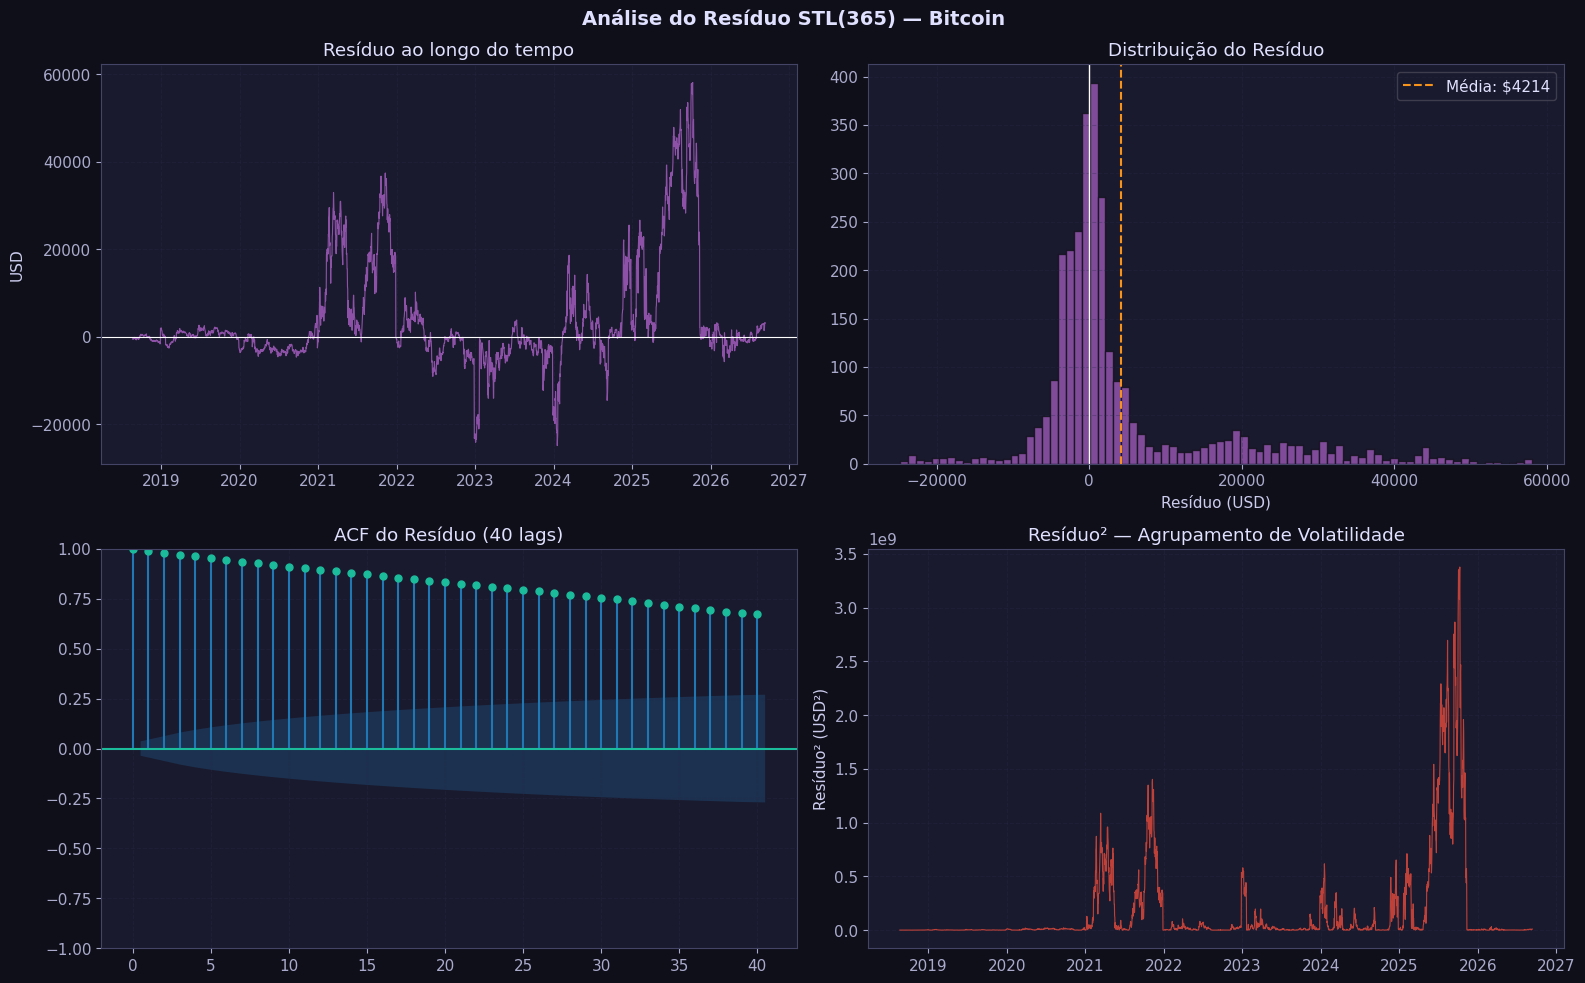


Estatísticas do Resíduo STL(365):
  Média:   $4214.43
  Desvio:  $12250.19
  Mín:     $-24828.57
  Máx:     $58116.21


In [11]:
residuo = pd.Series(res_365.resid, index=serie.index)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='#0f0f1a')
fig.suptitle('Análise do Resíduo STL(365) — Bitcoin',
             color='#e0e0ff', fontsize=14, fontweight='bold')

# Resíduo ao longo do tempo
axes[0,0].plot(residuo.index, residuo.values, color='#9b59b6', linewidth=0.8, alpha=0.9)
axes[0,0].axhline(0, color='#ffffff', linewidth=0.8)
axes[0,0].set_title('Resíduo ao longo do tempo', color='#e0e0ff')
axes[0,0].set_ylabel('USD')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0,0].xaxis.set_major_locator(mdates.YearLocator())
axes[0,0].grid(True, alpha=0.3)

# Histograma do resíduo
axes[0,1].hist(residuo.dropna(), bins=80, color='#9b59b6', alpha=0.8, edgecolor='#0f0f1a')
axes[0,1].axvline(0, color='#ffffff', linewidth=1)
axes[0,1].axvline(residuo.mean(), color='#f7931a', linestyle='--', linewidth=1.5,
                  label=f'Média: ${residuo.mean():.0f}')
axes[0,1].set_title('Distribuição do Resíduo', color='#e0e0ff')
axes[0,1].set_xlabel('Resíduo (USD)')
axes[0,1].legend(framealpha=0.2)
axes[0,1].grid(True, alpha=0.3)

# ACF do resíduo
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuo.dropna(), lags=40, ax=axes[1,0], color='#1abc9c',
         title='ACF do Resíduo (40 lags)')
axes[1,0].title.set_color('#e0e0ff')
axes[1,0].set_facecolor('#1a1a2e')
axes[1,0].grid(True, alpha=0.3)

# Resíduo² (volatilidade do resíduo)
axes[1,1].plot(residuo.index, residuo.values**2, color='#e74c3c', linewidth=0.8, alpha=0.8)
axes[1,1].set_title('Resíduo² — Agrupamento de Volatilidade', color='#e0e0ff')
axes[1,1].set_ylabel('Resíduo² (USD²)')
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1,1].xaxis.set_major_locator(mdates.YearLocator())
axes[1,1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_17_residuo_stl.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print(f'\nEstatísticas do Resíduo STL(365):')
print(f'  Média:   ${residuo.mean():.2f}')
print(f'  Desvio:  ${residuo.std():.2f}')
print(f'  Mín:     ${residuo.min():.2f}')
print(f'  Máx:     ${residuo.max():.2f}')

## 8. Exportação dos Componentes STL

In [12]:
# Exportar componentes STL para uso nos notebooks seguintes
df_stl = pd.DataFrame({
    'date'         : serie.index,
    'observed'     : res_365.observed.values,
    'trend_365'    : res_365.trend.values,
    'seasonal_365' : res_365.seasonal.values,
    'resid_365'    : res_365.resid.values,
    'trend_7'      : res_7.trend.values,
    'seasonal_7'   : res_7.seasonal.values,
    'resid_7'      : res_7.resid.values,
    'trend_30'     : res_30.trend.values,
    'seasonal_30'  : res_30.seasonal.values,
    'resid_30'     : res_30.resid.values,
})
df_stl.to_csv(OUTPUT_DIR / 'bitcoin_stl_components.csv', index=False)
print('Arquivo exportado: bitcoin_stl_components.csv')
print(f'Shape: {df_stl.shape}')
df_stl.head()

Arquivo exportado: bitcoin_stl_components.csv
Shape: (2943, 11)


,date,observed,trend_365,seasonal_365,resid_365,trend_7,seasonal_7,resid_7,trend_30,seasonal_30,resid_30
0,2018-08-22,6376.71,3853.894139,3008.921736,-486.105876,6568.147464,-109.254634,-82.182830,6805.025649,-263.070404,-165.245244
1,2018-08-23,6534.88,3866.726793,3228.338536,-560.185329,6629.538549,-140.767221,46.108673,6796.619026,-137.813247,-123.925779
2,2018-08-24,6719.96,3879.554681,3202.261200,-361.855881,6691.211040,-65.358879,94.107839,6788.242599,-23.185932,-45.096667
3,2018-08-25,6763.19,3892.377770,3245.721500,-374.909270,6753.419856,-33.062144,42.832288,6779.904485,-30.881801,14.167315
4,2018-08-26,6707.26,3905.196026,3208.408922,-406.344947,6816.029765,-50.591786,-58.177979,6771.613960,-111.869625,47.515665


## 9. Resumo da Decomposição STL

| Componente | Período | Observação |
|------------|---------|------------|
| **Tendência** | — | Forte tendência de alta de longo prazo com ciclos de bull/bear market de ~4 anos (halvings). Identifica claramente: crash 2018-19, bull run 2020-21, bear 2022, novo ciclo 2023+ |
| **Sazonalidade Semanal** | 7d | Fs ≈ baixo; padrão semanal existe mas é fraco em relação à magnitude da série |
| **Sazonalidade Mensal** | 30d | Fs moderado; alguns meses historicamente mais fortes |
| **Sazonalidade Anual** | 365d | Fs moderado; captura padrões relacionados aos ciclos de halving |
| **Resíduo** | — | Concentrado perto de zero com eventos extremos; resíduo² mostra agrupamento de volatilidade (ARCH) |
| **Força da Tendência** | — | Ft muito alta (>0.9) — tendência domina a série |

**Impactos para modelagem:**
- Holt-Winters: usar `trend='add'` e testar `seasonal='add'` com período 7
- SARIMAX: usar `d=1`, testar `D=1` com `s=7` (semanal) ou `s=365` (anual)
- RF/XGBoost: componente de tendência capturado pelos lags; sazonalidade pelos encodings cíclicos

**Próximo passo:** `02_modelos/`